In [1]:
# !pip install rdkit 

In [2]:
import cudaq
from src.unitary_library import unitary, controlled_adjoint_unitary, controlled_unitary
from src.train import train_transformer
import os
import pandas as pd

In [3]:
cudaq.set_target("nvidia")

@cudaq.kernel
def build_sequence_only_circuit_(
    token_i: list[float],
    position_i: list[float],
    query: list[float],
    token_j: list[float],
    position_j: list[float],
    key: list[float],
    ansatz_layers: list[int],
    num_working_qubits: list[int],
):
    layers = ansatz_layers[0]
    ancilla = cudaq.qubit()
    register = cudaq.qvector(num_working_qubits[0])
    subsystem_size = num_working_qubits[0] // 2

    h(ancilla)
    unitary(register, token_i, subsystem_size, 0, layers)
    unitary(register, position_i, subsystem_size, 1, layers)
    unitary(register, query, subsystem_size, -1, layers)
    controlled_adjoint_unitary(ancilla, register, query, subsystem_size, -1, layers)
    controlled_adjoint_unitary(ancilla, register, position_i, subsystem_size, 1, layers)
    controlled_adjoint_unitary(ancilla, register, token_i, subsystem_size, 0, layers)
    controlled_unitary(ancilla, register, token_j, subsystem_size, 0, layers)
    controlled_unitary(ancilla, register, position_j, subsystem_size, 1, layers)
    controlled_unitary(ancilla, register, key, subsystem_size, -1, layers)
    h(ancilla)

In [4]:
from cudaq import spin
import numpy as np

np.random.seed(42)


hamiltonian = spin.z(0)

ansatz_layers = 1
num_working_qubits = 6

# We will test the circuit which only accepts token and positional embeddings. In this case, these registers are represented by 3 qubits each
subsystem_size = 3


# Create dummy angles for the ansatz

# Since there is only rotation angle on each qubit in the ansatz,
# the number of angles required for each unitary is subsystem_size*ansatz_layers for the token and position encodings
# and num_working_qubits*ansatz_layers for the query and key, as these unitaries span the whole register
dummy_token_i = (np.random.random(subsystem_size * ansatz_layers) * 2 * np.pi).tolist()
dummy_position_i = (
    np.random.random(subsystem_size * ansatz_layers) * 2 * np.pi
).tolist()
dummy_query = (
    np.random.random(num_working_qubits * ansatz_layers) * 2 * np.pi
).tolist()

dummy_token_j = (np.random.random(subsystem_size * ansatz_layers) * 2 * np.pi).tolist()
dummy_position_j = (
    np.random.random(subsystem_size * ansatz_layers) * 2 * np.pi
).tolist()
dummy_key = (np.random.random(num_working_qubits * ansatz_layers) * 2 * np.pi).tolist()


observe_result = cudaq.observe(
    build_sequence_only_circuit_,
    hamiltonian,
    dummy_token_i,
    dummy_position_i,
    dummy_query,
    dummy_token_j,
    dummy_position_j,
    dummy_key,
    [ansatz_layers],
    [num_working_qubits],
)
print("Unscaled attention score: " + str(observe_result.expectation()))

print("Circuit:")
print(
    cudaq.draw(
        build_sequence_only_circuit_,
        dummy_token_i,
        dummy_position_i,
        dummy_query,
        dummy_token_j,
        dummy_position_j,
        dummy_key,
        [ansatz_layers],
        [num_working_qubits],
    )
)

Unscaled attention score: 0.32332373054859076
Circuit:
         ╭───╮                                                                »
q0 : ────┤ h ├────────────────────────────────────────────────────────────────»
     ╭───┴───┴───╮           ╭───╮╭───────────╮                          ╭───╮»
q1 : ┤ ry(2.353) ├───●───────┤ x ├┤ ry(0.365) ├───●──────────────────────┤ x ├»
     ├───────────┤ ╭─┴─╮     ╰─┬─╯├───────────┤ ╭─┴─╮                    ╰─┬─╯»
q2 : ┤ ry(5.974) ├─┤ x ├──●────┼──┤ ry(5.442) ├─┤ x ├──●───────────────────┼──»
     ├───────────┤ ╰───╯╭─┴─╮  │  ├───────────┤ ╰───╯╭─┴─╮                 │  »
q3 : ┤ ry(4.599) ├──────┤ x ├──●──┤ ry(3.777) ├──────┤ x ├──●──────────────┼──»
     ├───────────┤      ╰───╯╭───╮├───────────┤      ╰───╯╭─┴─╮            │  »
q4 : ┤ ry(3.761) ├───●───────┤ x ├┤ ry(4.449) ├───────────┤ x ├──●─────────┼──»
     ├───────────┴╮╭─┴─╮     ╰─┬─╯├───────────┴╮          ╰───╯╭─┴─╮       │  »
q5 : ┤ ry(0.9803) ├┤ x ├──●────┼──┤ ry(0.1293) ├───────────────┤ 

In [5]:
dummy_token_i = (np.random.random(subsystem_size * ansatz_layers) * 2 * np.pi).tolist()
dummy_position_i = (
    np.random.random(subsystem_size * ansatz_layers) * 2 * np.pi
).tolist()
dummy_query = (
    np.random.random(num_working_qubits * ansatz_layers) * 2 * np.pi
).tolist()

dummy_token_j = dummy_token_i
dummy_position_j = dummy_position_i
dummy_key = dummy_query


observe_result = cudaq.observe(
    build_sequence_only_circuit_,
    hamiltonian,
    dummy_token_i,
    dummy_position_i,
    dummy_query,
    dummy_token_j,
    dummy_position_j,
    dummy_key,
    [ansatz_layers],
    [num_working_qubits],
)
print("Unscaled attention score: " + str(observe_result.expectation()))

Unscaled attention score: 0.9999998277981461


In [6]:
from src.transformer import Transformer_Dataset
from src.train import ensure_training_data

is_small_dataset = True
dataset_name = f"./dataset/qm9{'_small' if is_small_dataset else ''}.csv"

ensure_training_data(training_data=dataset_name)

dataset = Transformer_Dataset(
    data_path=dataset_name, block_size=None
)  # If we set block_size to None, the class will infer the block size from the largest tokenized SMILES in the dataset
datapoint = dataset[42]
print(f"SMILES token indices: {datapoint[0].tolist()}")
tokenzied_datapoint = [dataset.itos[idx] for idx in datapoint[0].tolist()]
print(f"Tokenized SMILES: {tokenzied_datapoint}")

2026-03-04 19:35:02,031 [INFO] Training data found at: ./dataset/qm9_small.csv


SMILES token indices: [17, 11, 29, 4, 30, 29, 1, 12, 2, 30, 29, 1, 10, 13, 2, 31, 4, 18, 9, 9, 9, 9, 9]
Tokenized SMILES: ['[CLS]', 'C', 'c', '1', 'n', 'c', '(', 'F', ')', 'n', 'c', '(', '=', 'N', ')', 'o', '1', '[EOS]', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


In [7]:
if not os.path.exists("./dataset/qm9_small.csv"):
    # random only 1/10

    df = pd.read_csv("./dataset/qm9.csv")
    df_sample = df.sample(frac=0.1, random_state=42)
    df_sample.to_csv("./dataset/qm9_small.csv", index=False)

In [8]:
triethlyamine_example_indices = dataset.tokenize_smiles("CCN(CC)CC")
print(f"Indicies of triethlyamine after tokenization {triethlyamine_example_indices}")
triethlyamine_example_tokenzied = [
    dataset.itos[idx] for idx in triethlyamine_example_indices
]
print(f"Tokenized triethlyamine: {triethlyamine_example_tokenzied}")

Indicies of triethlyamine after tokenization [17, 11, 11, 13, 1, 11, 11, 2, 11, 11, 18, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]
Tokenized triethlyamine: ['[CLS]', 'C', 'C', 'N', '(', 'C', 'C', ')', 'C', 'C', '[EOS]', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


In [9]:
from torch import nn
import torch

embedding_matrix = nn.Embedding(
    len(dataset.vocab), 3
)  # Three is the embedding dimension, in our case the number of angles required for each unitary
triethlyamine_token_embeddings = embedding_matrix(
    torch.tensor(triethlyamine_example_indices)
)
print("Triethlyamine token embeddings:")
print(triethlyamine_token_embeddings)

Triethlyamine token embeddings:
tensor([[ 7.0793e-01, -1.0011e+00, -2.0848e+00],
        [-7.7665e-01,  1.3585e+00,  8.1864e-01],
        [-7.7665e-01,  1.3585e+00,  8.1864e-01],
        [ 1.2776e+00,  2.3911e-01, -1.1343e-01],
        [ 1.1505e+00, -2.1080e-01, -1.2331e+00],
        [-7.7665e-01,  1.3585e+00,  8.1864e-01],
        [-7.7665e-01,  1.3585e+00,  8.1864e-01],
        [-2.3175e-03,  7.1246e-01,  3.3104e-01],
        [-7.7665e-01,  1.3585e+00,  8.1864e-01],
        [-7.7665e-01,  1.3585e+00,  8.1864e-01],
        [-5.0852e-01,  5.4280e-01,  8.6023e-01],
        [ 2.7204e+00, -3.2365e-01,  2.7496e-01],
        [ 2.7204e+00, -3.2365e-01,  2.7496e-01],
        [ 2.7204e+00, -3.2365e-01,  2.7496e-01],
        [ 2.7204e+00, -3.2365e-01,  2.7496e-01],
        [ 2.7204e+00, -3.2365e-01,  2.7496e-01],
        [ 2.7204e+00, -3.2365e-01,  2.7496e-01],
        [ 2.7204e+00, -3.2365e-01,  2.7496e-01],
        [ 2.7204e+00, -3.2365e-01,  2.7496e-01],
        [ 2.7204e+00, -3.2365e-01,  2

In [10]:
from src.utils import get_physchem_properties, scale_to_range

triethylamine_example_properties = get_physchem_properties("CCN(CC)CC")
print("Triethylamine physicochemical properties:")
print(triethylamine_example_properties)

properties_linear_layer = nn.Linear(len(triethylamine_example_properties), 3)
triethylamine_physchem_embeddings = scale_to_range(
    properties_linear_layer(torch.tensor(triethylamine_example_properties)), 0, torch.pi
)

print("Triethylamine physicochemical embeddings:")
print(triethylamine_physchem_embeddings)

# Since the physicochemical embeddings all belong to the same molecule, they will be repeated for each token
triethylamine_physchem_embeddings = triethylamine_physchem_embeddings.unsqueeze(
    0
).expand(dataset.block_size, -1)

Triethylamine physicochemical properties:
[101.193, 1, 0, 3, 0, 1, 3.24, 1.3481, 0]
Triethylamine physicochemical embeddings:
tensor([1.5823, 0.0000, 3.1416], grad_fn=<AddBackward0>)


In [14]:
positional_embedding = nn.Parameter(torch.rand(dataset.block_size, 3))
print("Positional embeddings:")
print(positional_embedding)

query_angles = nn.Parameter(torch.rand(6))
print("Query angles:")
print(query_angles)

key_angles = nn.Parameter(torch.rand(6))
print("Key angles:")
print(key_angles)

Positional embeddings:
Parameter containing:
tensor([[0.5331, 0.5214, 0.3307],
        [0.5613, 0.3454, 0.5837],
        [0.4376, 0.5218, 0.2025],
        [0.1209, 0.3759, 0.5519],
        [0.0823, 0.0263, 0.7944],
        [0.8722, 0.9120, 0.2548],
        [0.7611, 0.3797, 0.7673],
        [0.4546, 0.4914, 0.9487],
        [0.4571, 0.0299, 0.0433],
        [0.2272, 0.9518, 0.6227],
        [0.3428, 0.5457, 0.2017],
        [0.0213, 0.2769, 0.2576],
        [0.7255, 0.5314, 0.7626],
        [0.8594, 0.9781, 0.1576],
        [0.7417, 0.5844, 0.2168],
        [0.6369, 0.7940, 0.5061],
        [0.0466, 0.5167, 0.4524],
        [0.9487, 0.3311, 0.9665],
        [0.8653, 0.5796, 0.1249],
        [0.9814, 0.9807, 0.4977],
        [0.7372, 0.9389, 0.7457],
        [0.3989, 0.8571, 0.9782],
        [0.6803, 0.2974, 0.8846],
        [0.5375, 0.2943, 0.7326]], requires_grad=True)
Query angles:
Parameter containing:
tensor([0.5253, 0.2429, 0.1738, 0.4691, 0.5282, 0.9320], requires_grad=True)
Key a

In [15]:
@cudaq.kernel
def build_physchem_embeddings_circuit(
    token_i: list[float],
    position_i: list[float],
    physchem: list[float],
    query: list[float],
    token_j: list[float],
    position_j: list[float],
    key: list[float],
    ansatz_layers: list[int],
    num_working_qubits: list[int],
):
    layers = ansatz_layers[0]
    ancilla = cudaq.qubit()
    register = cudaq.qvector(num_working_qubits[0])
    subsystem_size_use = 2

    h(ancilla)  # noqa: F821
    unitary(register, token_i, subsystem_size_use, 0, layers)
    unitary(register, position_i, subsystem_size_use, 1, layers)
    unitary(register, physchem, subsystem_size_use, 2, layers)

    unitary(register, query, subsystem_size_use, -1, layers)
    controlled_adjoint_unitary(ancilla, register, query, subsystem_size_use, -1, layers)

    controlled_adjoint_unitary(ancilla, register, position_i, subsystem_size_use, 1, layers)
    controlled_adjoint_unitary(ancilla, register, token_i, subsystem_size_use, 0, layers)

    controlled_unitary(ancilla, register, token_j, subsystem_size_use, 0, layers)
    controlled_unitary(ancilla, register, position_j, subsystem_size_use, 1, layers)

    controlled_unitary(ancilla, register, key, subsystem_size_use, -1, layers)
    h(ancilla)  # noqa: F821


triethylamine_token_i = triethlyamine_token_embeddings[1].detach().numpy().tolist()
triethylamine_position_i = positional_embedding[1].detach().numpy().tolist()

triethylamine_token_j = triethlyamine_token_embeddings[3].detach().numpy().tolist()
triethylamine_position_j = positional_embedding[3].detach().numpy().tolist()

triethylamine_physchem = triethylamine_physchem_embeddings[3].detach().numpy().tolist()
triethylamine_query = query_angles.detach().numpy().tolist()
triethylamine_key = key_angles.detach().numpy().tolist()


observe_result = cudaq.observe(
    build_physchem_embeddings_circuit,
    hamiltonian,
    triethylamine_token_i,
    triethylamine_position_i,
    triethylamine_physchem,
    triethylamine_query,
    triethylamine_token_j,
    triethylamine_position_j,
    triethylamine_key,
    [ansatz_layers],
    [num_working_qubits],
)
print("Unscaled attention score: " + str(observe_result.expectation()))

Unscaled attention score: 0.450502248330066


In [13]:
assert False

AssertionError: 

In [ ]:
train_transformer(
    training_data=dataset_name,
    checkpoint_dir="./checkpoints/classical_example/",
    checkpoint_resume_path=None,
    learning_rate=0.005,
    weight_decay=0.1,
    batch_size=256,
    epochs=3,
    save_every_n_batches=0,
    validation_split=0.05,
    attn_type="classical",
    num_qubits=6,
    ansatz_layers=1,
    conditional_training=False,
    quantum_gradient_method="spsa",
    spsa_epsilon=0.01,
    sample_percentage=1.0,
    seed=42,
    classical_parameter_reduction=True,
    device="gpu",
    qpu_count=-1,
)

2026-02-25 09:14:41,260 [INFO] Note reproducability between device architectures is not garunteed.
2026-02-25 09:14:41,261 [INFO] Checkpoint directory set at: ./checkpoints/classical_example/
2026-02-25 09:14:41,261 [INFO] Quantum target set to: nvidia with QPU count: 1
2026-02-25 09:14:41,262 [INFO] Using device: cuda:0
2026-02-25 09:14:41,262 [INFO] Training data found at: ./dataset/qm9_small.csv
2026-02-25 09:14:41,994 [INFO] Loaded 12717 training samples and 669 validation samples from a total of 13386 samples (100.00% of the canonicalized dataset).


Saving training SMILES: 100%|██████████| 12717/12717 [00:02<00:00, 4853.09it/s]
2026-02-25 09:14:44,616 [INFO] Training SMILES strings with properties saved to ./training_splits/train_dataset_2026-02-25_09-14-41.csv.
Saving validation SMILES: 100%|██████████| 669/669 [00:00<00:00, 4823.20it/s]
2026-02-25 09:14:44,756 [INFO] Validation SMILES strings with properties saved to ./validation_splits/val_dataset_2026-02-25_09-14-41.csv.
2026-02-25 09:14:44,792 [INFO] Transformer model initialized.
2026-02-25 09:14:44,794 [INFO] Initialized classical model with shared weights to ensure same initialization between models
2026-02-25 09:14:45,260 [INFO] Optimizer, scaler, and loss function initialized.
2026-02-25 09:14:45,261 [INFO] Data loaders created.
2026-02-25 09:14:45,261 [INFO] Starting training...
Epoch 3/3; Validation Loss: 0.8126: 100%|██████████| 3/3 [00:00<00:00, 20.11it/s]


In [ ]:
train_transformer(
    training_data=dataset_name,
    checkpoint_dir="./checkpoints/classical_example_conditions/",
    checkpoint_resume_path=None,
    learning_rate=0.005,
    weight_decay=0.1,
    batch_size=256,
    epochs=3,
    save_every_n_batches=0,
    validation_split=0.05,
    attn_type="classical",
    num_qubits=6,
    ansatz_layers=1,
    conditional_training=True,
    quantum_gradient_method="spsa",
    spsa_epsilon=0.01,
    sample_percentage=1.0,
    seed=42,
    classical_parameter_reduction=True,
    device="gpu",
    qpu_count=-1,
)

2026-02-25 09:15:41,606 [INFO] Note reproducability between device architectures is not garunteed.
2026-02-25 09:15:41,606 [INFO] Checkpoint directory set at: ./checkpoints/classical_example_conditions/
2026-02-25 09:15:41,607 [INFO] Quantum target set to: nvidia with QPU count: 1
2026-02-25 09:15:41,607 [INFO] Using device: cuda:0
2026-02-25 09:15:41,608 [INFO] Training data found at: ./dataset/qm9_small.csv
2026-02-25 09:15:42,276 [INFO] Loaded 12717 training samples and 669 validation samples from a total of 13386 samples (100.00% of the canonicalized dataset).


Saving training SMILES: 100%|██████████| 12717/12717 [00:02<00:00, 5025.34it/s]
2026-02-25 09:15:44,807 [INFO] Training SMILES strings with properties saved to ./training_splits/train_dataset_2026-02-25_09-15-41.csv.
Saving validation SMILES: 100%|██████████| 669/669 [00:00<00:00, 5044.93it/s]
2026-02-25 09:15:44,941 [INFO] Validation SMILES strings with properties saved to ./validation_splits/val_dataset_2026-02-25_09-15-41.csv.
2026-02-25 09:15:44,956 [INFO] Transformer model initialized.
2026-02-25 09:15:44,959 [INFO] Initialized classical model with shared weights to ensure same initialization between models
2026-02-25 09:15:44,960 [INFO] Optimizer, scaler, and loss function initialized.
2026-02-25 09:15:44,960 [INFO] Data loaders created.
2026-02-25 09:15:44,960 [INFO] Starting training...
Epoch 3/3; Validation Loss: 0.9065: 100%|██████████| 3/3 [00:00<00:00, 19.52it/s]


In [ ]:
train_transformer(
    training_data=dataset_name,
    checkpoint_dir="./checkpoints/quantum_example/",
    checkpoint_resume_path="./checkpoints/quantum_example/model_epoch_2.pt",
    learning_rate=0.005,
    weight_decay=0.1,
    batch_size=256,
    epochs=1,
    save_every_n_batches=0,
    validation_split=0.05,
    attn_type="quantum",
    num_qubits=6,
    ansatz_layers=1,
    conditional_training=False,
    quantum_gradient_method="spsa",
    spsa_epsilon=0.01,
    sample_percentage=1.0,
    seed=42,
    classical_parameter_reduction=True,
    device="gpu",
    qpu_count=-1,
)

2026-03-04 18:01:55,798 [WARNING] Different number of epochs detected for 'epochs': 3 != 1
2026-03-04 18:01:55,799 [INFO] Note reproducability between device architectures is not garunteed.
2026-03-04 18:01:55,799 [INFO] Checkpoint directory set at: ./checkpoints/quantum_example/
2026-03-04 18:01:55,803 [INFO] Quantum target set to: nvidia with QPU count: 1
2026-03-04 18:01:55,803 [INFO] Using device: cuda:0
2026-03-04 18:01:55,803 [INFO] Training data found at: ./dataset/qm9_small.csv
2026-03-04 18:01:56,519 [INFO] Loaded 12717 training samples and 669 validation samples from a total of 13386 samples (100.00% of the canonicalized dataset).


Saving training SMILES: 100%|██████████| 12717/12717 [00:02<00:00, 5048.36it/s]
2026-03-04 18:01:59,040 [INFO] Training SMILES strings with properties saved to ./training_splits/train_dataset_2026-03-04_18-01-55.csv.
Saving validation SMILES: 100%|██████████| 669/669 [00:00<00:00, 4905.16it/s]
2026-03-04 18:01:59,178 [INFO] Validation SMILES strings with properties saved to ./validation_splits/val_dataset_2026-03-04_18-01-55.csv.
2026-03-04 18:01:59,193 [INFO] Transformer model initialized.
2026-03-04 18:01:59,659 [INFO] Optimizer, scaler, and loss function initialized.
2026-03-04 18:01:59,663 [INFO] Previous training losses: [1.3270614051818848, 0.9980905532836915], Previous validation losses: [1.0319972038269043, 0.9473007520039877], Starting at epoch 3 and batch 1 
2026-03-04 18:01:59,663 [INFO] Data loaders created.
2026-03-04 18:01:59,665 [INFO] Starting training...


In [17]:
train_transformer(
    training_data=dataset_name,
    checkpoint_dir="./checkpoints/quantum_example_2/",
    checkpoint_resume_path=None,
    learning_rate=0.005,
    weight_decay=0.1,
    batch_size=256,
    epochs=1,
    save_every_n_batches=0,
    validation_split=0.05,
    attn_type="quantum",
    num_qubits=6,
    ansatz_layers=1,
    conditional_training=False,
    quantum_gradient_method="spsa",
    spsa_epsilon=0.01,
    sample_percentage=1.0,
    seed=42,
    classical_parameter_reduction=True,
    device="gpu",
    qpu_count=-1,
)

2026-03-04 19:36:35,075 [INFO] Note reproducability between device architectures is not garunteed.
2026-03-04 19:36:35,075 [INFO] Checkpoint directory set at: ./checkpoints/quantum_example_2/
2026-03-04 19:36:35,076 [INFO] Quantum target set to: nvidia with QPU count: 1
2026-03-04 19:36:35,076 [INFO] Using device: cuda:0
2026-03-04 19:36:35,077 [INFO] Training data found at: ./dataset/qm9_small.csv
2026-03-04 19:36:35,732 [INFO] Loaded 12717 training samples and 669 validation samples from a total of 13386 samples (100.00% of the canonicalized dataset).


Saving training SMILES: 100%|██████████| 12717/12717 [00:02<00:00, 5062.62it/s]
2026-03-04 19:36:38,246 [INFO] Training SMILES strings with properties saved to ./training_splits/train_dataset_2026-03-04_19-36-35.csv.
Saving validation SMILES: 100%|██████████| 669/669 [00:00<00:00, 4915.71it/s]
2026-03-04 19:36:38,383 [INFO] Validation SMILES strings with properties saved to ./validation_splits/val_dataset_2026-03-04_19-36-35.csv.
2026-03-04 19:36:38,398 [INFO] Transformer model initialized.
2026-03-04 19:36:38,399 [INFO] Optimizer, scaler, and loss function initialized.
2026-03-04 19:36:38,399 [INFO] Data loaders created.
2026-03-04 19:36:38,400 [INFO] Starting training...
Epoch 1/1; Validation Loss: 1.0320: 100%|██████████| 3/3 [00:16<00:00,  5.66s/it]


In [ ]:
train_transformer(
    training_data=dataset_name,
    checkpoint_dir="./checkpoints/quantum_example_conditions/",
    checkpoint_resume_path=None,
    learning_rate=0.005,
    weight_decay=0.1,
    batch_size=256,
    epochs=1,
    save_every_n_batches=0,
    validation_split=0.05,
    attn_type="quantum",
    num_qubits=6,
    ansatz_layers=1,
    conditional_training=True,
    quantum_gradient_method="spsa",
    spsa_epsilon=0.01,
    sample_percentage=1.0,
    seed=42,
    classical_parameter_reduction=True,
    device="gpu",
    qpu_count=-1,
)

2026-03-04 18:02:20,908 [INFO] Note reproducability between device architectures is not garunteed.
2026-03-04 18:02:20,908 [INFO] Checkpoint directory set at: ./checkpoints/quantum_example_conditions/
2026-03-04 18:02:20,909 [INFO] Quantum target set to: nvidia with QPU count: 1
2026-03-04 18:02:20,909 [INFO] Using device: cuda:0
2026-03-04 18:02:20,909 [INFO] Training data found at: ./dataset/qm9_small.csv
2026-03-04 18:02:21,547 [INFO] Loaded 12717 training samples and 669 validation samples from a total of 13386 samples (100.00% of the canonicalized dataset).


Saving training SMILES: 100%|██████████| 12717/12717 [00:02<00:00, 5193.25it/s]
2026-03-04 18:02:23,997 [INFO] Training SMILES strings with properties saved to ./training_splits/train_dataset_2026-03-04_18-02-20.csv.
Saving validation SMILES: 100%|██████████| 669/669 [00:00<00:00, 5213.54it/s]
2026-03-04 18:02:24,126 [INFO] Validation SMILES strings with properties saved to ./validation_splits/val_dataset_2026-03-04_18-02-20.csv.
2026-03-04 18:02:24,128 [INFO] Transformer model initialized.
2026-03-04 18:02:24,128 [INFO] Optimizer, scaler, and loss function initialized.
2026-03-04 18:02:24,128 [INFO] Data loaders created.
2026-03-04 18:02:24,128 [INFO] Starting training...
Epoch 1/1; Training Loss: 3.6089:   2%|▏         | 1/50 [00:51<42:23, 51.91s/it]


KeyboardInterrupt: 

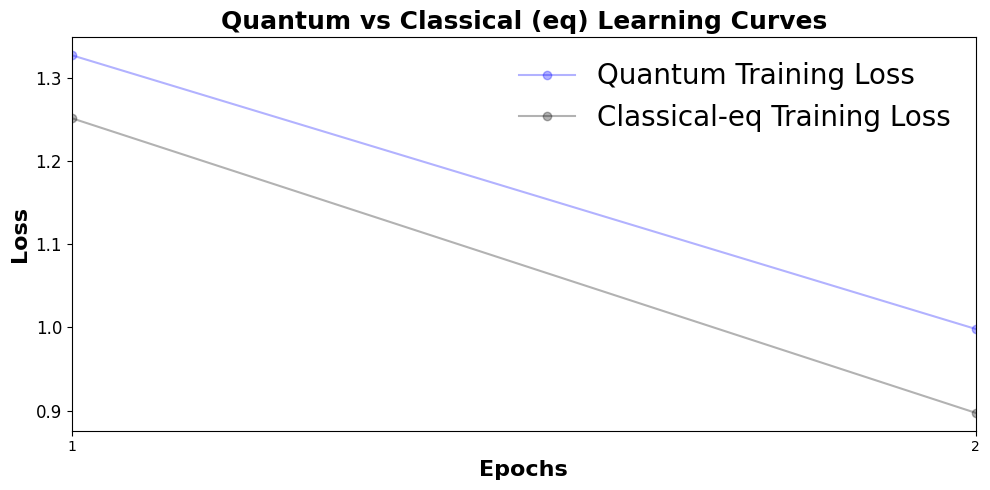

FileNotFoundError: [Errno 2] No such file or directory: './checkpoints/quantum_example_conditions/model_epoch_1.pt'

In [ ]:
from src.analysis import generate_plots_from_checkpoint

generate_plots_from_checkpoint(
    quantum_checkpoint_path="./checkpoints/quantum_example/model_epoch_2.pt",
    classical_equal_param_checkpoint_path="./checkpoints/classical_example/model_epoch_2.pt",
    title="Quantum vs Classical (eq) Learning Curves",
    plot_train_losses=True,
    show_plot=True,
)

generate_plots_from_checkpoint(
    quantum_checkpoint_path="./checkpoints/quantum_example_conditions/model_epoch_1.pt",
    classical_equal_param_checkpoint_path="./checkpoints/classical_example_conditions/model_epoch_1.pt",
    title="Quantum vs Classical (cond) Learning Curves",
    plot_train_losses=True,
    show_plot=True,
)

In [ ]:
from src.analysis import generate_smiles

valid, unique, novel = generate_smiles(
    checkpoint_path="./checkpoints/classical_example/model_epoch_3.pt",
    save_dir="./generated_molecules/classical_example.csv",
    choose_best_val_epoch=True,
    num_of_model_queries=1000,
    sampling_batch_size=250,
    device="gpu",
)


print(f"Valid: {valid:.2f}%")
print(f"Unique: {unique:.2f}%")
print(f"Novel: {novel:.2f}%")

In [ ]:
generate_smiles(
    checkpoint_path="./checkpoints/classical_example_conditions/model_epoch_3.pt",
    save_dir="./generated_molecules/classical_example_conditions_MW_120.csv",
    num_of_model_queries=1000,
    sampling_batch_size=250,
    device="gpu",
    MW=120,
)

MW_120_target = pd.read_csv(
    "./generated_molecules/classical_example_conditions_MW_120.csv"
)["MW"].mean()

generate_smiles(
    checkpoint_path="./checkpoints/classical_example_conditions/model_epoch_3.pt",
    save_dir="./generated_molecules/classical_example_conditions_MW_80.csv",
    num_of_model_queries=1000,
    sampling_batch_size=250,
    device="gpu",
    MW=80,
)

MW_80_target = pd.read_csv(
    "./generated_molecules/classical_example_conditions_MW_80.csv"
)["MW"].mean()

print(" ")
print(f"Average molecular weight for molecules with MW=120: {MW_120_target:.2f}")
print(f"Average molecular weight for molecules with MW=80: {MW_80_target:.2f}")